In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set()

In [109]:
df = pd.read_csv('customer_churn_data.csv',keep_default_na=False)

In [110]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,None,2208.32,No,Yes


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  1000 non-null   object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [112]:
df['InternetService'].unique()

array(['Fiber Optic', 'DSL', 'None'], dtype=object)

In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [115]:
Q1 = df['Tenure'].quantile(0.25)
Q3 = df['Tenure'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Tenure'] < Q1 - 1.5*IQR) | (df['Tenure'] > Q3 + 1.5*IQR)]
df_clean = df[~((df['Tenure'] < Q1 - 1.5*IQR) | (df['Tenure'] > Q3 + 1.5*IQR))]

In [116]:
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

In [117]:
df_clean.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,502.446219,44.726305,15.582535,74.336337,1147.410415,0.889244
std,291.359387,9.842938,13.432146,25.687877,1112.451571,0.313997
min,1.000000,12.000000,0.000000,30.000000,0.000000,0.000000
25%,250.500000,38.000000,5.000000,52.055000,332.070000,1.000000
50%,505.000000,45.000000,12.000000,73.960000,796.320000,1.000000
75%,755.500000,51.000000,24.000000,96.080000,1612.820000,1.000000
max,1000.000000,83.000000,57.000000,119.960000,6389.040000,1.000000


In [118]:
#Why is it important

In [119]:
# Overall churn rate
churn_rate = df_clean['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.1f}%")

# Revenue lost
churned_revenue = df_clean[df_clean['Churn']==1]['MonthlyCharges'].sum()
print(f"Monthly Revenue Lost: {churned_revenue:,.0f}")

Overall Churn Rate: 88.9%
Monthly Revenue Lost: 63,220


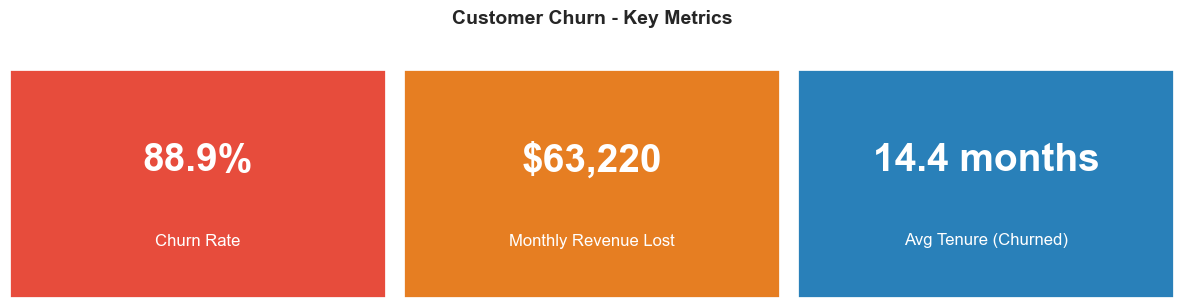

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

kpis = [
    {
        'title': 'Churn Rate',
        'value': f"{df_clean['Churn'].mean() * 100:.1f}%",
        'color': '#e74c3c'
    },
    {
        'title': 'Monthly Revenue Lost',
        'value': f"${df_clean[df_clean['Churn']==1]['MonthlyCharges'].sum():,.0f}",
        'color': '#e67e22'
    },
    {
        'title': 'Avg Tenure (Churned)',
        'value': f"{df_clean[df_clean['Churn']==1]['Tenure'].mean():.1f} months",
        'color': '#2980b9'
    }
]

for ax, kpi in zip(axes, kpis):
    ax.set_facecolor(kpi['color'])
    ax.text(0.5, 0.6, kpi['value'], transform=ax.transAxes,
            fontsize=28, fontweight='bold', color='white',
            ha='center', va='center')
    ax.text(0.5, 0.25, kpi['title'], transform=ax.transAxes,
            fontsize=12, color='white',
            ha='center', va='center')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Customer Churn - Key Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [121]:
CATEGORY_COLUMNS = [
    "Gender",
    "ContractType",
    "InternetService",
    "TechSupport"
    
]
def segment_percentages(df_clean, columns):
    results = {}
    for col in columns:
        if col not in df_clean.columns:
            print(f"[skip] column '{col}' not found in data")
            continue
        counts = df_clean[col].value_counts(dropna=False)
        pct = (counts / len(df) * 100).round(2)
        summary = pd.DataFrame({"count": counts, "percentage": pct})
        summary.index.name = col
        results[col] = summary
    return results

results = segment_percentages(df, CATEGORY_COLUMNS)
for col, summary in results.items():
    print(f"\n=== {col} ===")
    display(summary)


=== Gender ===


,count,percentage
Gender,,
Female,538,53.8
Male,462,46.2



=== ContractType ===


,count,percentage
ContractType,,
Month-to-Month,511,51.1
One-Year,289,28.9
Two-Year,200,20.0



=== InternetService ===


,count,percentage
InternetService,,
Fiber Optic,395,39.5
DSL,308,30.8
None,297,29.7



=== TechSupport ===


,count,percentage
TechSupport,,
Yes,506,50.6
No,494,49.4


In [122]:
 #What went wrong?

In [123]:
#Pricing And Contract

In [124]:
bins = [0,55, 90, 120]
labels = ["Low", "Medium", "High"]

df_clean["PriceLevels"] = pd.cut(df_clean["MonthlyCharges"], bins=bins, labels=labels)

In [125]:
#ChurnRate at different price level
df_clean.groupby('PriceLevels')['Churn'].mean().mul(100).round(1)

PriceLevels
Low       84.8
Medium    87.0
High      95.0
Name: Churn, dtype: float64

In [126]:
df_clean.groupby('Churn')['MonthlyCharges'].median()

Churn
0    60.78
1    78.23
Name: MonthlyCharges, dtype: float64

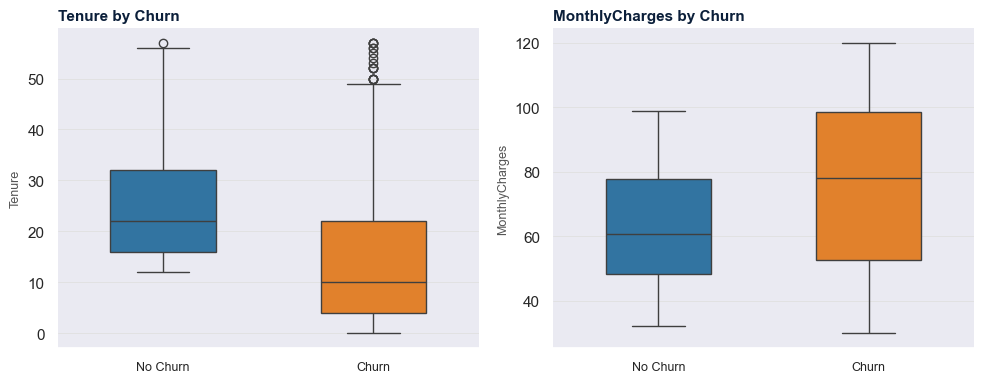

In [127]:
#Dis
navy = '#0B1F3A'
steel_blue = '#4C6A92'

num_features = ['Tenure', 'MonthlyCharges']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, feature in zip(axes, num_features):
    sns.boxplot(
        data=df_clean, x='Churn', y=feature, hue='Churn', legend=False, ax=ax,
        order=[0, 1], palette=['#1f77b4', '#ff7f0e'], width=0.5
    )
    ax.set_title(f'{feature} by Churn', fontsize=11, fontweight='bold', color=navy, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel(feature, fontsize=9, color='#555555')
    ax.set_xticklabels(['No Churn', 'Churn'], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [128]:

# ── 1. Churn Rate for different Contract type,Internet Service,TechSupport(yes/no),Gender ────────────────────────────────────────────
churn_rate = df_clean['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(churn_rate)


overall_rate = df_clean['Churn'].mean() * 100
print(f"\nOverall churn rate: {overall_rate:.1f}%")


# ── 2. Class Imbalance Check ─────────────────────────────────
counts = df_clean['Churn'].value_counts()
ratio  = counts.max() / counts.min()

print(f"\nClass counts:  {counts.to_dict()}")
print(f"Imbalance ratio: {ratio:.1f}:1")

if ratio < 1.5:
    verdict = "Balanced "
elif ratio < 4:
    verdict = "Mild imbalance" 
else:
    verdict = "Severe imbalance" 

print(f"Verdict: {verdict}")


# ── 3. Churn Rate by Key Segments ────────────────────────────

segments = ['ContractType', 'InternetService', 'TechSupport', 'Gender']
for col in segments:
    rates = df_clean.groupby(col)['Churn'].mean().mul(100).round(1)
    print(f"\nChurn rate by {col}:\n{rates}")

Churn distribution:
Churn
1    88.924388
0    11.075612
Name: proportion, dtype: float64

Overall churn rate: 88.9%

Class counts:  {1: 835, 0: 104}
Imbalance ratio: 8.0:1
Verdict: Severe imbalance

Churn rate by ContractType:
ContractType
Month-to-Month    100.0
One-Year           76.1
Two-Year           79.0
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
DSL             84.5
Fiber Optic     84.0
None           100.0
Name: Churn, dtype: float64

Churn rate by TechSupport:
TechSupport
No     100.0
Yes     78.3
Name: Churn, dtype: float64

Churn rate by Gender:
Gender
Female    88.3
Male      89.7
Name: Churn, dtype: float64


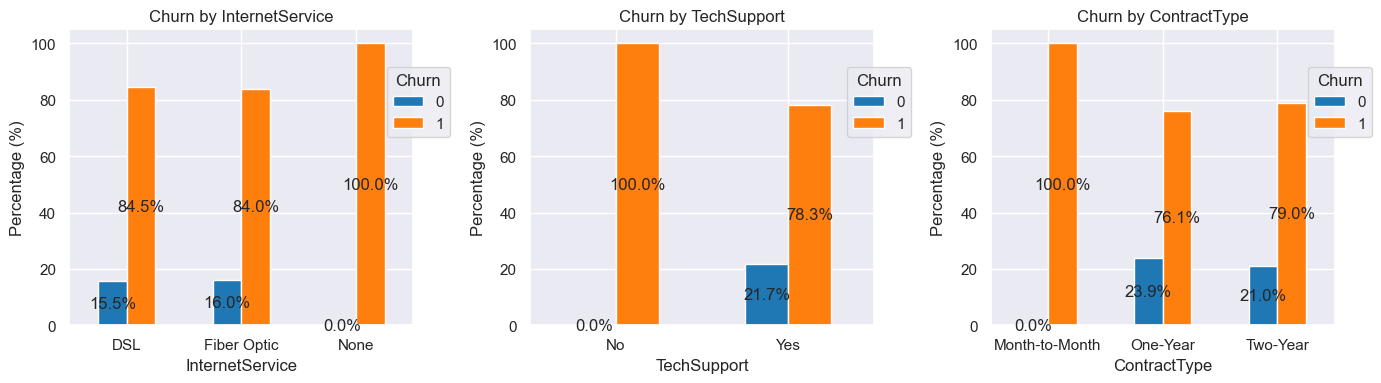

In [129]:
#visualization of Churn rate for InternetServices,TechSupport and ContractType Segment
features = ['InternetService', 'TechSupport', 'ContractType']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feature in zip(axes, features):
    total_counts = df_clean.groupby(feature)['Churn'].value_counts(normalize=True).unstack() * 100
    total_counts.plot(kind='bar', stacked=False, ax=ax, color=['#1f77b4', '#ff7f0e'])
    
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')
    
    ax.set_title(f'Churn by {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Churn', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

In [130]:
#churn contribution (share of all churned customers) at each price level, for all Contract Type,Internet Service and Tech Support
for col in ['ContractType', 'PriceLevels', 'InternetService', 'TechSupport']:
    churned_share = df_clean[df_clean['Churn']==1][col].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{col} — share of total churn:\n{churned_share}")


ContractType — share of total churn:
ContractType
Month-to-Month    57.6
One-Year          24.8
Two-Year          17.6
Name: proportion, dtype: float64

PriceLevels — share of total churn:
PriceLevels
Medium    38.3
High      34.3
Low       27.4
Name: proportion, dtype: float64

InternetService — share of total churn:
InternetService
Fiber Optic    37.1
None           33.5
DSL            29.3
Name: proportion, dtype: float64

TechSupport — share of total churn:
TechSupport
No     55.1
Yes    44.9
Name: proportion, dtype: float64


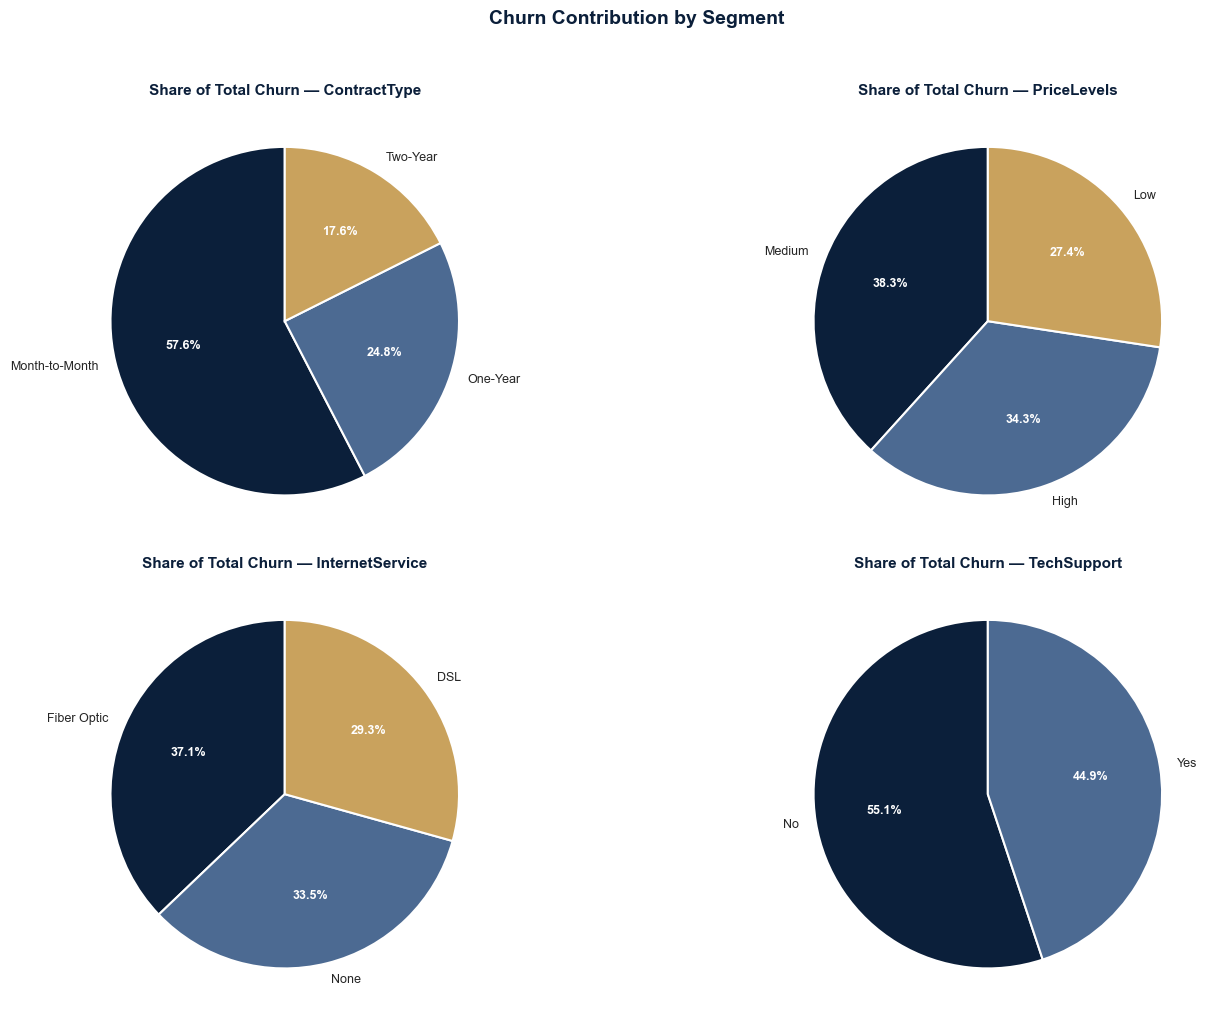

In [131]:
plt.close('all')

navy = '#0B1F3A'
steel_blue = '#4C6A92'
warm_grey = '#B7B7A4'
accent_gold = '#C9A25D'
palette = [navy, steel_blue, accent_gold, warm_grey, '#7A8B99', '#D9CBB3']

cols = ['ContractType', 'PriceLevels', 'InternetService', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    churned_share = df_clean[df_clean['Churn'] == 1][col].value_counts(normalize=True).mul(100).round(1)

    wedges, texts, autotexts = ax.pie(
        churned_share.values,
        labels=churned_share.index.astype(str),
        autopct='%1.1f%%',
        colors=palette[:len(churned_share)],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
    for text in texts:
        text.set_fontsize(9)

    ax.set_title(f'Share of Total Churn — {col}', fontsize=11, fontweight='bold', color=navy)



plt.suptitle('Churn Contribution by Segment', fontsize=14, fontweight='bold', color=navy, y=1.02)
plt.tight_layout()
plt.show()

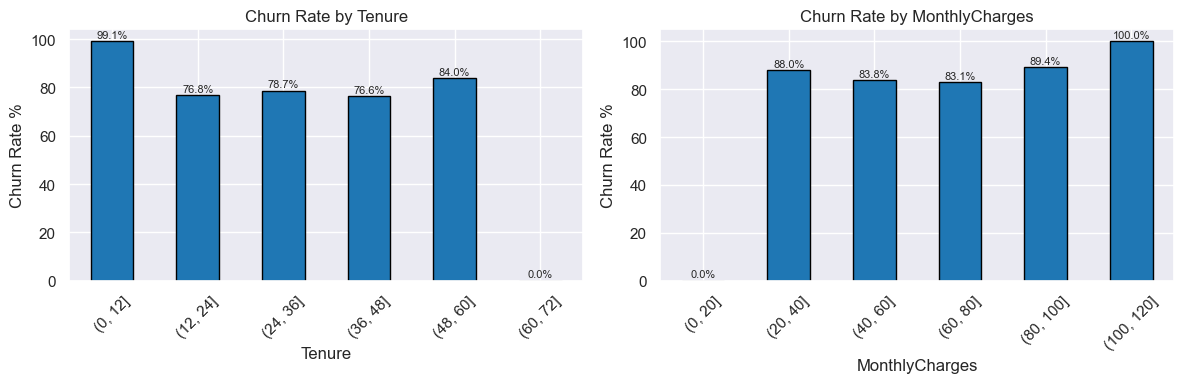

In [132]:
numerical_cols = ['Tenure', 'MonthlyCharges']
bins_dict = {
    'Tenure':         [0, 12, 24, 36, 48, 60, 72],
    'MonthlyCharges': [0, 20, 40, 60, 80, 100, 120],
}   

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, numerical_cols):
    df_clean[f'{col}_band'] = pd.cut(df_clean[col], bins=bins_dict[col])
    churn_rate = df_clean.groupby(f'{col}_band')['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color='#1f77b4', edgecolor='black')
    
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
                f'{p.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate %')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [133]:
#Where it went wrong

In [134]:
# At what month do most customers churn?
print(df_clean[df_clean['Churn']==1]['Tenure'].describe())

count    835.000000
mean      14.362874
std       13.155273
min        0.000000
25%        4.000000
50%       10.000000
75%       22.000000
max       57.000000
Name: Tenure, dtype: float64


In [135]:
c1=df_clean['ContractType'][(df_clean['ContractType']=='Month-to-Month') & (df_clean['Tenure']>12) &(df_clean['Churn']==1)].count()
c2=df_clean['ContractType'][(df_clean['Churn']==1) &(df_clean['ContractType']=='Month-to-Month')].count()
#percent of cutomer having month to month contrat and are churning after 12 months
print("percent of cutomer having month to month contrat and are churning after 12 months=", c1/c2*100)

percent of cutomer having month to month contrat and are churning after 12 months= 46.98544698544699


In [136]:
check = df_clean[
    (df_clean['ContractType']=='Month-to-Month') & 
    (df_clean['InternetService']=='DSL') & 
    (df_clean['PriceLevels']=='Low') & 
    (df_clean['TechSupport']=='No')
]
print(check['Churn'].value_counts())

Churn
1    11
Name: count, dtype: int64


In [137]:
contribution = (
    df_clean.groupby(['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], observed=True)
    .size()
    .reset_index(name='n')
)
contribution['pct_of_total_dataset'] = (contribution['n'] / len(df_clean) * 100).round(2)

churned = df_clean[df_clean['Churn'] == 1]
churn_contribution = (
    churned.groupby(['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], observed=True)
    .size()
    .reset_index(name='n_churned')
)
churn_contribution['pct_of_total_churn'] = (churn_contribution['n_churned'] / len(churned) * 100).round(2)

not_churned = df_clean[df_clean['Churn'] == 0]
nonchurn_contribution = (
    not_churned.groupby(['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], observed=True)
    .size()
    .reset_index(name='n_not_churned')
)
nonchurn_contribution['pct_of_total_nonchurn'] = (nonchurn_contribution['n_not_churned'] / len(not_churned) * 100).round(2)

summary = contribution.merge(
    churn_contribution, on=['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], how='left'
).merge(
    nonchurn_contribution, on=['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], how='left'
)

# Only fill the NUMERIC columns, not the categorical grouping columns
numeric_cols = ['n', 'pct_of_total_dataset', 'n_churned', 'pct_of_total_churn', 'n_not_churned', 'pct_of_total_nonchurn']
summary[numeric_cols] = summary[numeric_cols].fillna(0)


summary

,ContractType,PriceLevels,InternetService,TechSupport,n,pct_of_total_dataset,n_churned,pct_of_total_churn,n_not_churned,pct_of_total_nonchurn
0,Month-to-Month,Low,DSL,No,11,1.17,11,1.32,0.0,0.00
1,Month-to-Month,Low,DSL,Yes,29,3.09,29,3.47,0.0,0.00
2,Month-to-Month,Low,Fiber Optic,No,15,1.60,15,1.80,0.0,0.00
3,Month-to-Month,Low,Fiber Optic,Yes,34,3.62,34,4.07,0.0,0.00
4,Month-to-Month,Low,None,No,36,3.83,36,4.31,0.0,0.00
5,Month-to-Month,Medium,DSL,No,21,2.24,21,2.51,0.0,0.00
6,Month-to-Month,Medium,DSL,Yes,40,4.26,40,4.79,0.0,0.00
7,Month-to-Month,Medium,Fiber Optic,No,20,2.13,20,2.40,0.0,0.00
8,Month-to-Month,Medium,Fiber Optic,Yes,48,5.11,48,5.75,0.0,0.00
9,Month-to-Month,Medium,None,No,66,7.03,66,7.90,0.0,0.00


In [138]:
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0,25,35,45,55,65,100],
                                labels=['<25','25-34','35-44','45-54','55-64','65+'])
df_clean.groupby('AgeGroup', observed=True)['Churn'].mean().mul(100).round(1)

AgeGroup
<25       78.9
25-34     88.2
35-44     88.9
45-54     88.3
55-64     91.7
65+      100.0
Name: Churn, dtype: float64

<Axes: xlabel='AgeGroup', ylabel='Count'>

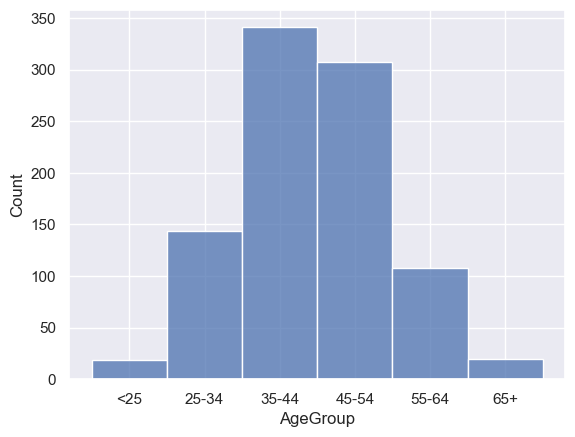

In [139]:
sns.histplot(data=df_clean,x='AgeGroup')

% churn within 12 months of total customers (question 3.4 — never computed, only churned-customer tenure stats were):

In [140]:
df_clean['TenureGroup'] = pd.cut(df_clean['Tenure'], bins=[0,10,20,30,122],
                                labels=['<10','10-20','20-30','30+'])
df_clean.groupby('TenureGroup', observed=True)['Churn'].mean().mul(100).round(1)

TenureGroup
<10      100.0
10-20     79.1
20-30     80.4
30+       78.3
Name: Churn, dtype: float64

In [141]:
median_tenure_churned = df.loc[df['Churn'] == 'Yes', 'Tenure'].median()
print(f"Median tenure (churned customers): {median_tenure_churned:.0f} months")

Median tenure (churned customers): 11 months


In [142]:
within_12mo = df_clean[df_clean['Tenure'] <= 12]
churn_rate_within_12mo = (within_12mo['Churn'].sum() / len(df_clean)) * 100
churn_rate_within_12mo

np.float64(51.75718849840255)

In [143]:
within_12mo_longterm = df_clean[
    (df_clean['Tenure'] <= 12) & (df_clean['ContractType'].isin(["One-Year", "Two-Year"]))
]
churn_rate_within_12mo_longterm = (within_12mo_longterm['Churn'].sum() / len(df_clean)) * 100
churn_rate_within_12mo_longterm

np.float64(24.600638977635782)

In [144]:
within_12mo_monthtomonth = df_clean[
    (df_clean['Tenure'] <= 12) & (df_clean['ContractType'].isin(["Month-to-Month"]))
]
churn_rate_within_12mo_monthtomonth = (within_12mo_monthtomonth['Churn'].sum() / len(df_clean)) * 100
churn_rate_within_12mo_monthtomonth

np.float64(27.15654952076677)

In [145]:
df_clean['TotalChargesBand'] = pd.cut(df_clean['TotalCharges'], bins=[0,500,1500,3000,15000],
                                        labels=['Low','Medium','High','Very High'])
df_clean.groupby('TotalChargesBand', observed=True)['Churn'].mean().mul(100).round(1)

TotalChargesBand
Low          99.3
Medium       84.0
High         80.3
Very High    87.0
Name: Churn, dtype: float64

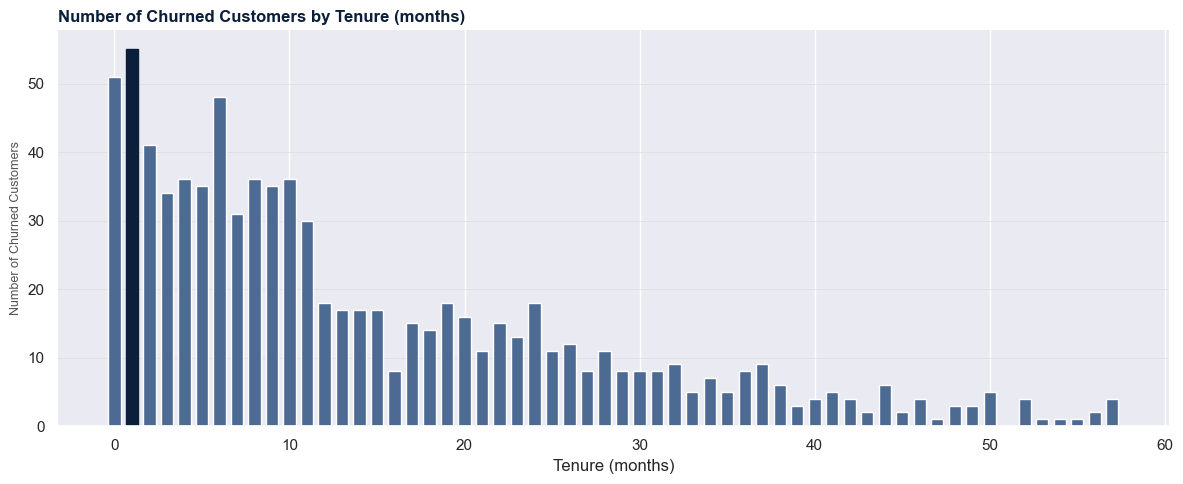

Tenure month contributing most churned customers: 1 months, with 55 churned customers


In [146]:
navy = '#0B1F3A'
steel_blue = '#4C6A92'

# Count of churned customers at each exact tenure month
churn_counts_by_tenure = df_clean[df_clean['Churn'] == 1]['Tenure'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(churn_counts_by_tenure.index, churn_counts_by_tenure.values, color=steel_blue, edgecolor='white', width=0.7)

# Highlight the peak month in navy
peak_tenure = churn_counts_by_tenure.idxmax()
peak_count = churn_counts_by_tenure.max()
bars[list(churn_counts_by_tenure.index).index(peak_tenure)].set_color(navy)

ax.set_title('Number of Churned Customers by Tenure (months)', fontsize=12, fontweight='bold', color=navy, loc='left')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Churned Customers', fontsize=9, color='#555555')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', color='#E0E0E0', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Tenure month contributing most churned customers: {peak_tenure} months, with {peak_count} churned customers")

In [147]:
baseline=88.9

In [148]:
Internet_Service_Churn_Rate = df_clean.groupby('InternetService')['Churn'].mean().mul(100).round(1)
baseline = df_clean['Churn'].mean() * 100
# for any segment table:
Internet_Service_Churn_Rate- baseline  # this "lift" column tells you real signal vs noise

InternetService
DSL            -4.424388
Fiber Optic    -4.924388
None           11.075612
Name: Churn, dtype: float64

In [149]:
Contract_Type_Churn_Rate = df_clean.groupby('ContractType')['Churn'].mean().mul(100).round(1)
baseline = df_clean['Churn'].mean() * 100
# for any segment table:
Contract_Type_Churn_Rate- baseline  # this "lift" column tells you real signal vs noise

ContractType
Month-to-Month    11.075612
One-Year         -12.824388
Two-Year          -9.924388
Name: Churn, dtype: float64

In [150]:
Price_Levels_Churn_Rate = df_clean.groupby('PriceLevels')['Churn'].mean().mul(100).round(1)
baseline = df_clean['Churn'].mean() * 100
# for any segment table:
Price_Levels_Churn_Rate- baseline  # this "lift" column tells you real signal vs noise

PriceLevels
Low      -4.124388
Medium   -1.924388
High      6.075612
Name: Churn, dtype: float64

In [151]:
# Uses your existing 'summary' table (ContractType x PriceRange x InternetService x TechSupport)
# Recompute churn_rate per combination first
combo_rates = (
    df_clean.groupby(['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'], observed=True)['Churn']
    .agg(churn_rate='mean', n='count')
)
combo_rates['churn_rate'] = (combo_rates['churn_rate'] * 100).round(1)
combo_rates = combo_rates.reset_index()

# Merge in pct_of_total_churn from your summary table
combo_rates = combo_rates.merge(
    summary[['ContractType', 'PriceLevels', 'InternetService', 'TechSupport', 'pct_of_total_churn']],
    on=['ContractType', 'PriceLevels', 'InternetService', 'TechSupport'],
    how='left'
)

# Filter out tiny, unreliable cells first (e.g. n < 15)
reliable = combo_rates[combo_rates['n'] >= 15]

# Now rank by a combined view: high risk AND high contribution
top_intersections = reliable.sort_values(['pct_of_total_churn', 'churn_rate'], ascending=[False, False])
top_intersections

,ContractType,PriceLevels,InternetService,TechSupport,churn_rate,n,pct_of_total_churn
9,Month-to-Month,Medium,None,No,100.0,66,7.90
13,Month-to-Month,High,Fiber Optic,Yes,100.0,51,6.11
8,Month-to-Month,Medium,Fiber Optic,Yes,100.0,48,5.75
14,Month-to-Month,High,None,No,100.0,48,5.75
6,Month-to-Month,Medium,DSL,Yes,100.0,40,4.79
24,One-Year,Medium,None,No,100.0,37,4.43
4,Month-to-Month,Low,None,No,100.0,36,4.31
3,Month-to-Month,Low,Fiber Optic,Yes,100.0,34,4.07
11,Month-to-Month,High,DSL,Yes,100.0,30,3.59
1,Month-to-Month,Low,DSL,Yes,100.0,29,3.47


In [152]:
drivers = {}
for col in ['ContractType', 'PriceLevels', 'InternetService', 'TechSupport', 'Gender']:
    rates = df_clean.groupby(col, observed=True)['Churn'].mean() * 100
    drivers[col] = {
        'min_rate': round(rates.min(), 1),
        'max_rate': round(rates.max(), 1),
        'spread': round(rates.max() - rates.min(), 1)
    }

driver_summary = pd.DataFrame(drivers).T.sort_values('spread', ascending=False)
driver_summary

,min_rate,max_rate,spread
ContractType,76.1,100.0,23.9
TechSupport,78.3,100.0,21.7
InternetService,84.0,100.0,16.0
PriceLevels,84.8,95.0,10.2
Gender,88.3,89.7,1.5


In [153]:
combo_stats = df_clean.groupby(['ContractType', 'InternetService', 'PriceLevels', 'TechSupport']).agg(
    total_count=('Churn', 'count'),
    churn_count=('Churn', 'sum')   # ← Churn is already 0/1, so sum() gives the count directly
).reset_index()
combo_stats['churn_rate_pct'] = (combo_stats['churn_count'] / combo_stats['total_count'] * 100).round(1)
combo_stats['churn_rate_pct'] = (combo_stats['churn_count'] / combo_stats['total_count'] * 100).round(1)
print(combo_stats[combo_stats['TechSupport'] == 'No'].to_string())

      ContractType InternetService PriceLevels TechSupport  total_count  churn_count  churn_rate_pct
0   Month-to-Month             DSL         Low          No           11           11           100.0
2   Month-to-Month             DSL      Medium          No           21           21           100.0
4   Month-to-Month             DSL        High          No           14           14           100.0
6   Month-to-Month     Fiber Optic         Low          No           15           15           100.0
8   Month-to-Month     Fiber Optic      Medium          No           20           20           100.0
10  Month-to-Month     Fiber Optic        High          No           18           18           100.0
12  Month-to-Month            None         Low          No           36           36           100.0
14  Month-to-Month            None      Medium          No           66           66           100.0
16  Month-to-Month            None        High          No           48           48       

In [154]:
df_clean.groupby(['InternetService', 'TechSupport']).size().unstack(fill_value=0)

TechSupport,No,Yes
InternetService,,
DSL,84,206
Fiber Optic,96,273
None,280,0


In [155]:
# 1. Row count and shape — does this look like a full customer base or a filtered pull?
print(df_clean.shape)
print(df_clean['Churn'].value_counts())

# 2. Check for duplicate customer IDs (if you have a CustomerID column)
print(df_clean['CustomerID'].duplicated().sum())

# 3. Trace back to the raw file — what's the churn rate in the RAW file, before any of your cleaning steps?
df_raw = pd.read_csv('customer_churn_data.csv', keep_default_na=False, na_values=[''])
print(df_raw['Churn'].value_counts(normalize=True) * 100)

(939, 16)
Churn
1    835
0    104
Name: count, dtype: int64
0
Churn
Yes    88.3
No     11.7
Name: proportion, dtype: float64


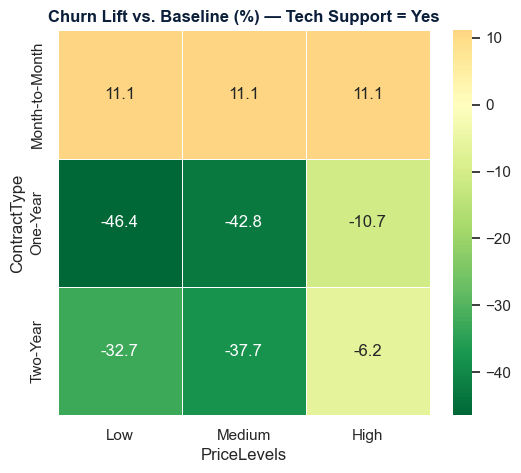

In [156]:
subset = df_clean[(df_clean['TechSupport'] == 'Yes') & (df_clean['InternetService'] != 'None')]
pivot = subset.pivot_table(index='ContractType', columns='PriceLevels', values='Churn', aggfunc='mean') * 100
pivot_lift = (pivot - baseline).round(1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot_lift, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Churn Lift vs. Baseline (%) — Tech Support = Yes', fontweight='bold', color=navy)
plt.savefig('chart_4_3.png', dpi=200, bbox_inches='tight', facecolor='white')

In [157]:
subset.pivot_table(index='ContractType', columns='PriceLevels', values='Churn', aggfunc='count')

PriceLevels,Low,Medium,High
ContractType,,,
Month-to-Month,63,88,81
One-Year,47,52,46
Two-Year,32,41,29


InternetService
Fiber Optic    369
DSL            290
None           280
Name: count, dtype: int64
Baseline churn rate: 88.9%

--- n by cell, Price = Low ---
TechSupport        No   Yes
InternetService            
DSL              28.0  65.0
Fiber Optic      31.0  77.0
None             69.0   NaN

--- n by cell, Price = Medium ---
TechSupport         No   Yes
InternetService             
DSL               33.0  85.0
Fiber Optic       35.0  96.0
None             119.0   NaN

--- n by cell, Price = High ---
TechSupport        No    Yes
InternetService             
DSL              23.0   56.0
Fiber Optic      30.0  100.0
None             92.0    NaN


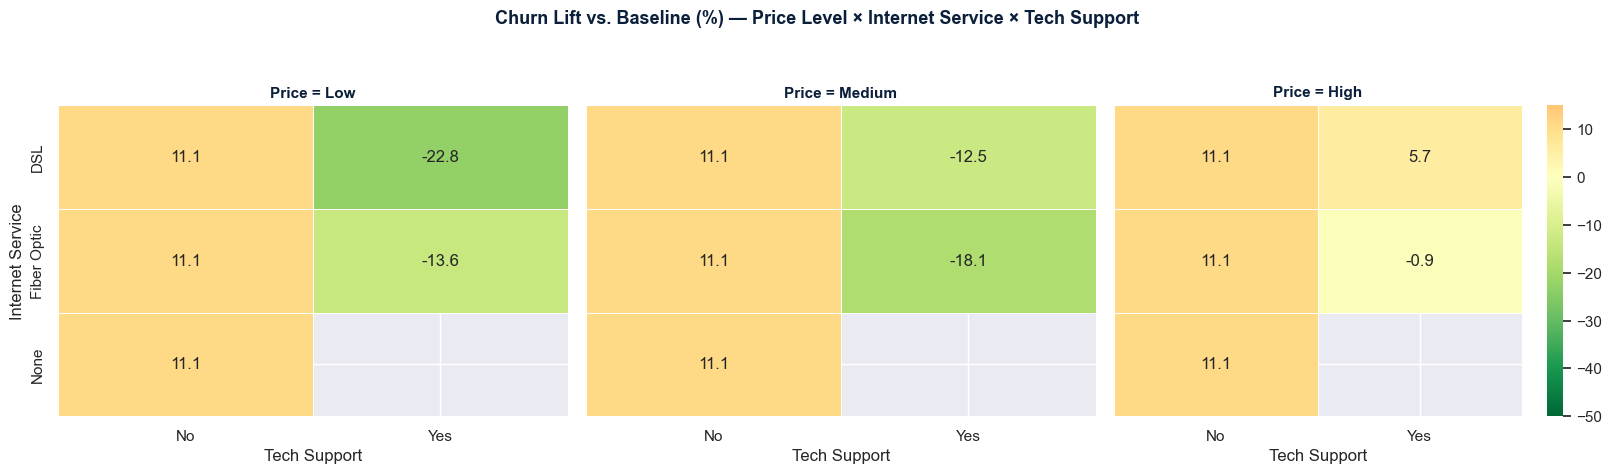

In [158]:
import pandas as pd


navy = '#0B1F3A'
steel_blue = '#4C6A92'



# Sanity check — InternetService should now show DSL / Fiber Optic / None,
# with zero NaN values
print(df_clean['InternetService'].value_counts(dropna=False))

# ── STEP 3: Baseline churn rate ──
baseline = df_clean['Churn'].mean() * 100
print(f"Baseline churn rate: {baseline:.1f}%")

# ── STEP 4: Build the 4.1 heatmap — Price Level × Internet Service × Tech Support ──
# Facets = Price Level, rows = Internet Service, columns = Tech Support
# Color = lift vs. baseline (not raw rate)

price_levels = df_clean['PriceLevels'].cat.categories if hasattr(df_clean['PriceLevels'], 'cat') else df_clean['PriceLevels'].unique()

fig, axes = plt.subplots(1, len(price_levels), figsize=(5.5 * len(price_levels), 4.5), sharey=True)

for j, price in enumerate(price_levels):
    ax = axes[j]
    subset = df_clean[df_clean['PriceLevels'] == price]

    pivot_rate = subset.pivot_table(
        index='InternetService', columns='TechSupport', values='Churn', aggfunc='mean'
    ) * 100
    pivot_n = subset.pivot_table(
        index='InternetService', columns='TechSupport', values='Churn', aggfunc='count'
    )
    pivot_lift = (pivot_rate - baseline).round(1)

    sns.heatmap(
        pivot_lift, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
        ax=ax, cbar=(j == len(price_levels) - 1),
        linewidths=0.5, linecolor='white', vmin=-50, vmax=15
    )
    ax.set_title(f'Price = {price}', fontsize=11, fontweight='bold', color=navy)
    ax.set_xlabel('Tech Support')
    if j == 0:
        ax.set_ylabel('Internet Service')
    else:
        ax.set_ylabel('')

    # print n underneath for reference / to paste into your write-up
    print(f"\n--- n by cell, Price = {price} ---")
    print(pivot_n)

plt.suptitle('Churn Lift vs. Baseline (%) — Price Level × Internet Service × Tech Support',
             fontsize=13, fontweight='bold', color=navy, y=1.05)
plt.tight_layout()
plt.savefig('chart_4_1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [159]:


total_customers = len(df_clean)

combo_stats_4_3 = df_clean.groupby(
    ['ContractType', 'PriceLevels', 'TechSupport']
).agg(
    n=('Churn', 'count'),
    churn_count=('Churn', 'sum')
).reset_index()

combo_stats_4_3['churn_rate_pct'] = (
    combo_stats_4_3['churn_count'] / combo_stats_4_3['n'] * 100
).round(1)

combo_stats_4_3['dataset_share_pct'] = (
    combo_stats_4_3['n'] / total_customers * 100
).round(1)

baseline = df_clean['Churn'].mean() * 100
combo_stats_4_3['lift_vs_baseline'] = (
    combo_stats_4_3['churn_rate_pct'] - baseline
).round(1)

# Flag statistically weak cells — adjust threshold as needed
min_n = 15
combo_stats_4_3['reliable'] = combo_stats_4_3['n'] >= min_n

# Sort by dataset share descending — biggest addressable segments first
combo_stats_4_3 = combo_stats_4_3.sort_values('dataset_share_pct', ascending=False).reset_index(drop=True)

print(f"Total customers: {total_customers}")
print(f"Baseline churn rate: {baseline:.1f}%\n")
print(combo_stats_4_3.to_string(index=False))

reliable_share = combo_stats_4_3[combo_stats_4_3['reliable']]['dataset_share_pct'].sum()
print(f"\n{combo_stats_4_3['reliable'].sum()} of {len(combo_stats_4_3)} combinations are statistically reliable (n>={min_n}),")
print(f"covering {reliable_share:.1f}% of the dataset.")

Total customers: 939
Baseline churn rate: 88.9%

  ContractType PriceLevels TechSupport   n  churn_count  churn_rate_pct  dataset_share_pct  lift_vs_baseline  reliable
Month-to-Month      Medium          No 107          107           100.0               11.4              11.1      True
Month-to-Month      Medium         Yes  88           88           100.0                9.4              11.1      True
Month-to-Month        High         Yes  81           81           100.0                8.6              11.1      True
Month-to-Month        High          No  80           80           100.0                8.5              11.1      True
Month-to-Month         Low         Yes  63           63           100.0                6.7              11.1      True
Month-to-Month         Low          No  62           62           100.0                6.6              11.1      True
      One-Year      Medium         Yes  52           24            46.2                5.5             -42.7      True